In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("loan_approval_dataset.csv")

In [5]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [7]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [8]:
print(df["education"].unique())

<ArrowStringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str


In [9]:
print(df["self_employed"].unique())

<ArrowStringArray>
[' No', ' Yes']
Length: 2, dtype: str


In [10]:
print(df["loan_status"].unique())

<ArrowStringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str


In [12]:
df["education"] = df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

df["self_employed"] = df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

df["loan_Status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

In [13]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_Status
0,1,2,NaN,NaN,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,NaN
1,2,0,NaN,NaN,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,NaN
2,3,3,NaN,NaN,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,NaN
3,4,3,NaN,NaN,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,NaN
4,5,5,NaN,NaN,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,NaN


In [14]:
x = df.drop(["loan_id", "loan_status"], axis=1)
y = df["loan_status"]

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
model = DecisionTreeClassifier(random_state=42)

In [21]:
model.fit(X_train, y_train)
print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [22]:
predictions = model.predict(X_test)
print(predictions[:10])

[' Rejected' ' Approved' ' Rejected' ' Approved' ' Approved' ' Approved'
 ' Approved' ' Rejected' ' Approved' ' Rejected']


In [23]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})
comparison.head(20)

,Actual,Predicted
0,Rejected,Rejected
1,Approved,Approved
2,Rejected,Rejected
3,Approved,Approved
4,Approved,Approved
5,Approved,Approved
6,Approved,Approved
7,Rejected,Rejected
8,Approved,Approved
9,Rejected,Rejected


In [24]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9754098360655737


In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

[[529   7]
 [ 14 304]]


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    Approved       0.97      0.99      0.98       536
    Rejected       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



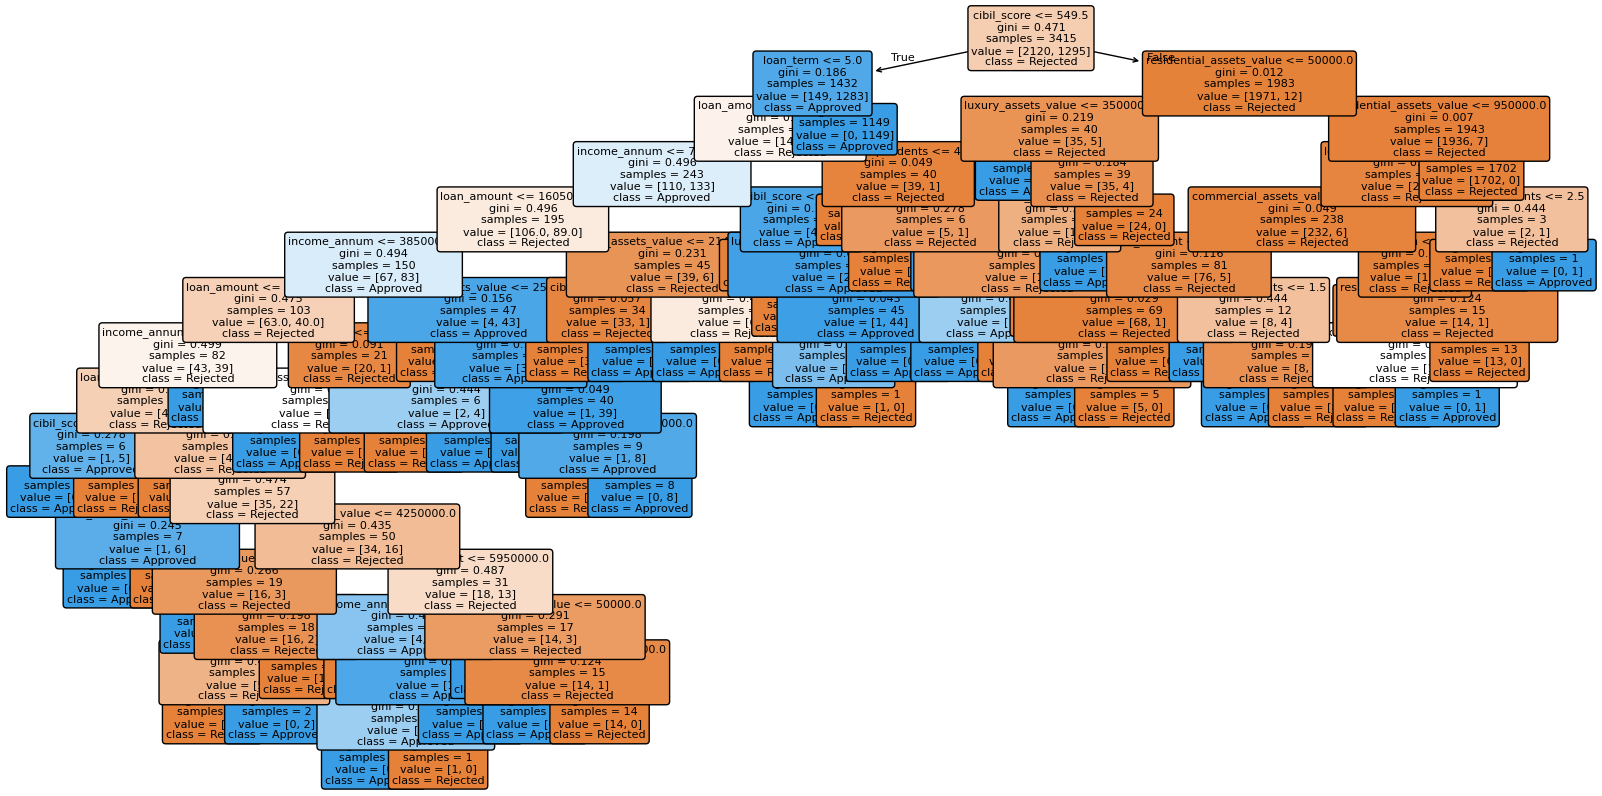

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [32]:
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [33]:
rf_predictions = rf_model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.9789227166276346


In [37]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending = False
)
print(importance)

                     Feature  Importance
6                cibil_score    0.808475
5                  loan_term    0.058958
4                loan_amount    0.029524
9        luxury_assets_value    0.020021
7   residential_assets_value    0.019832
3               income_annum    0.019263
8    commercial_assets_value    0.017736
10          bank_asset_value    0.017109
0           no_of_dependents    0.009081
1                  education    0.000000
2              self_employed    0.000000
11               loan_Status    0.000000


In [39]:
importance = rf_model.feature_importances_
print(importance)

[0.00908091 0.         0.         0.01926338 0.02952412 0.05895813
 0.80847485 0.01983223 0.01773642 0.02002124 0.01710872 0.        ]


In [42]:
import pandas as pd
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print(feature_importance)

                     Feature  Importance
6                cibil_score    0.808475
5                  loan_term    0.058958
4                loan_amount    0.029524
9        luxury_assets_value    0.020021
7   residential_assets_value    0.019832
3               income_annum    0.019263
8    commercial_assets_value    0.017736
10          bank_asset_value    0.017109
0           no_of_dependents    0.009081
1                  education    0.000000
2              self_employed    0.000000
11               loan_Status    0.000000


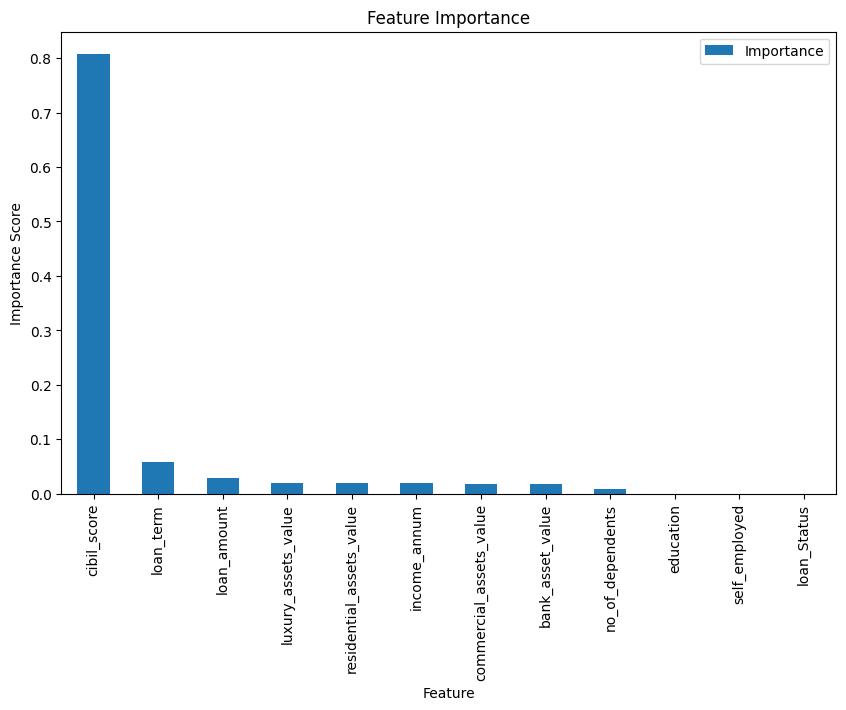

In [43]:
import matplotlib.pyplot as plt
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,6)
)
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [44]:
import joblib

joblib.dump(rf_model, "loan_approval_random_forest.pkl")

['loan_approval_random_forest.pkl']

In [45]:
model = joblib.load("loan_approval_random_forest.pkl")